Name: Pablo Rodríguez Elvira

# Pre-processing exercise

In this exercise you will pre-prcess the [California housing dataset](https://www.kaggle.com/camnugent/california-housing-prices).


### Tasks to complete the preprocessing pipeline

- **Basic inspection**
  - Check dataset structure using `shape`, `info()`, `describe()`, and category counts.

- **Missing values**
  - Handle missing data using a justified strategy (e.g., KNNImputer, median, etc.).
  - Verify that no missing values remain.

- **Outlier detection and treatment**
  - Identify extreme values in numerical features.
  - Apply a reasonable strategy (e.g., clipping, capping, or removing) and explain your choice.

- **Feature engineering**
  - Create new meaningful variables, for example:
    - `rooms_per_household = total_rooms / households`
    - `bedrooms_per_room = total_bedrooms / total_rooms`
    - `population_per_household = population / households`

- **Categorical encoding**
  - Convert categorical variables (like `ocean_proximity`) into one-hot encoded features.

- **Numerical transformations**
  - Scale or transform numerical features (StandardScaler, MinMax, Box-Cox, etc.).
  - Briefly explain why scaling helps ML models.

- **Clean preprocessing structure**
  - Organize preprocessing steps clearly (preferably using a pipeline or structured workflow).
  - Produce a final dataset ready to be used by a machine learning model.



In [98]:
#%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.precision', 3)

### Basic Inspection

In [99]:
from sklearn.neighbors import KNeighborsClassifier
housing = pd.read_csv("housing.csv", header=0, delimiter=',')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.325,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.301,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.257,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.643,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.846,342200.0,NEAR BAY


In [100]:
housing.shape

(20640, 10)

<Axes: xlabel='longitude', ylabel='latitude'>

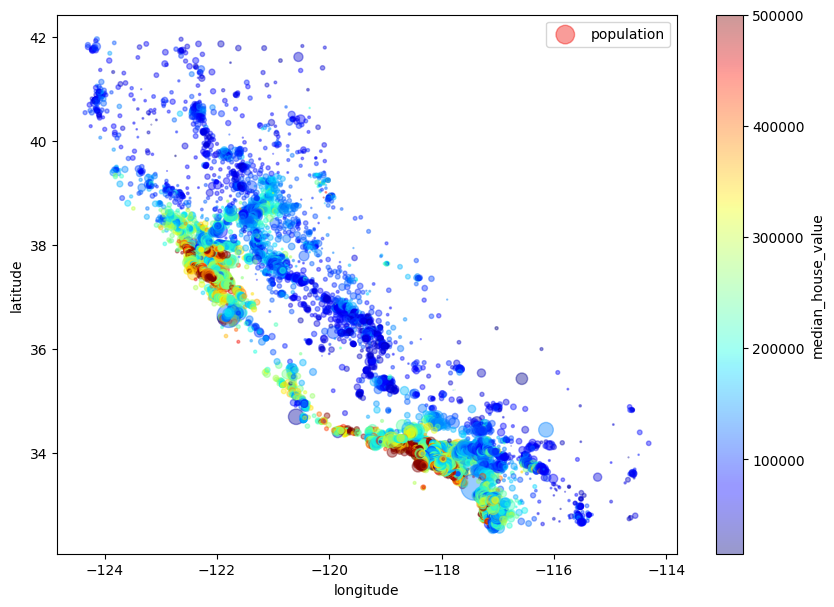

In [101]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
            s=housing["population"]/100, label="population", figsize=(10,7),
            c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)

In [102]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.00,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.54,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.33,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.00,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.00,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.00,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.00,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.00,15.000,500001.000


### Missing Values Imputation

First, we inspect how many NA's are in the dataset and where they are.

In [103]:
housing.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [104]:
subset_of_housing = housing.drop(columns=['total_bedrooms','ocean_proximity'])

In [105]:
subset_of_housing.shape
housing.shape

(20640, 8)

(20640, 10)

In [106]:
rows_not_missing = housing.total_bedrooms.notna()
rows_missing = housing.total_bedrooms.isna()
rows_not_missing.sum()
rows_missing.sum()

np.int64(20433)

np.int64(207)

In [107]:
housing_without_missings = subset_of_housing[rows_not_missing]
housing_without_missings.shape

(20433, 8)

We use KNN-Imputer to impute missing values in variable total_bedrooms

In [108]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(housing_without_missings, housing.total_bedrooms[rows_not_missing])
imputed_values = knn.predict(subset_of_housing[rows_missing]);

In [109]:
housing.loc[rows_missing, 'total_bedrooms'] = imputed_values

In [110]:
housing.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

<Axes: >

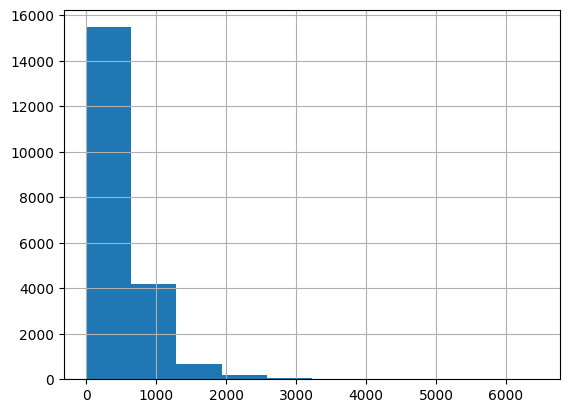

In [111]:
housing.total_bedrooms.hist()

### Outlier Detection

,feature,n_outliers,pct_outliers,lower_bound,upper_bound
3,total_rooms,1287,6.235,-1102.625,5698.375
4,total_bedrooms,1279,6.197,-231.125,1173.875
6,households,1220,5.911,-207.500,1092.500
5,population,1196,5.795,-620.000,3132.000
7,median_income,681,3.299,-0.706,8.013
2,housing_median_age,0,0.000,-10.500,65.500
0,longitude,0,0.000,-127.485,-112.325
1,latitude,0,0.000,28.260,43.380


array([[<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'median_income'}>, <Axes: >]],
      dtype=object)

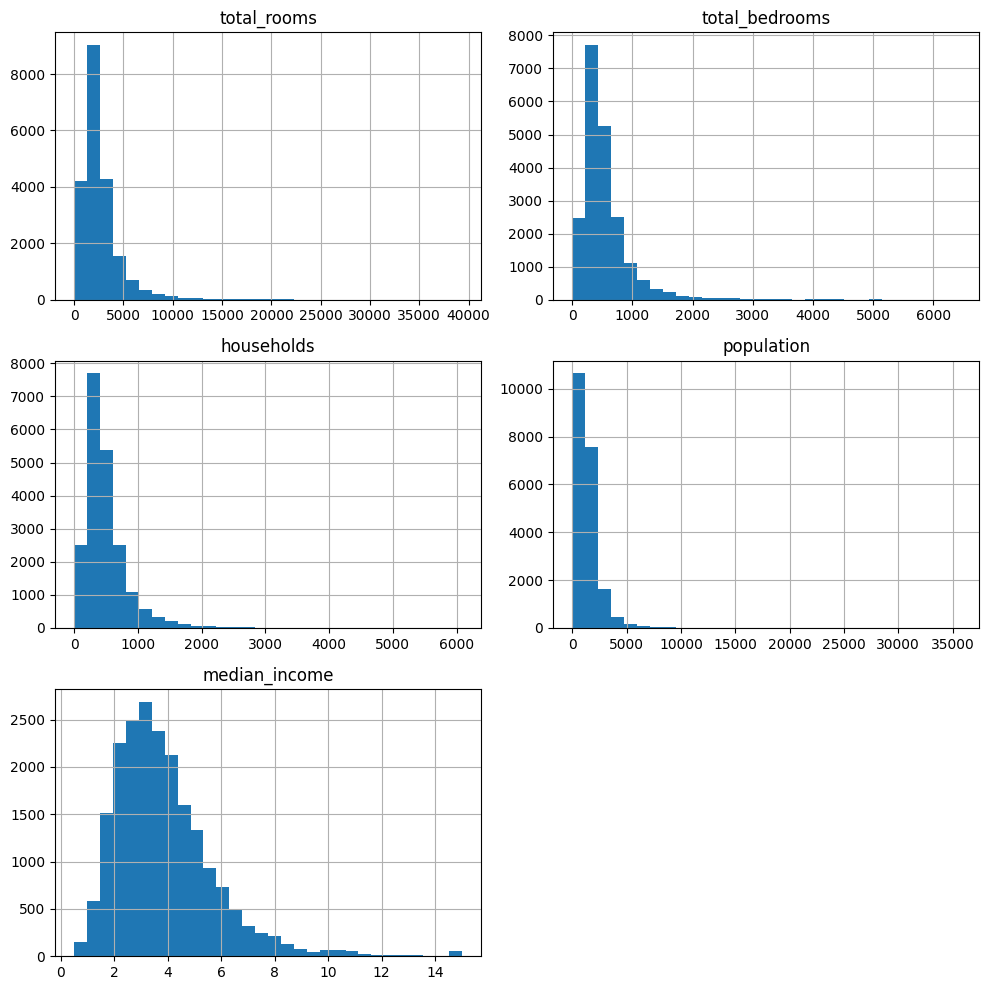

<Figure size 1400x600 with 0 Axes>

<Axes: >

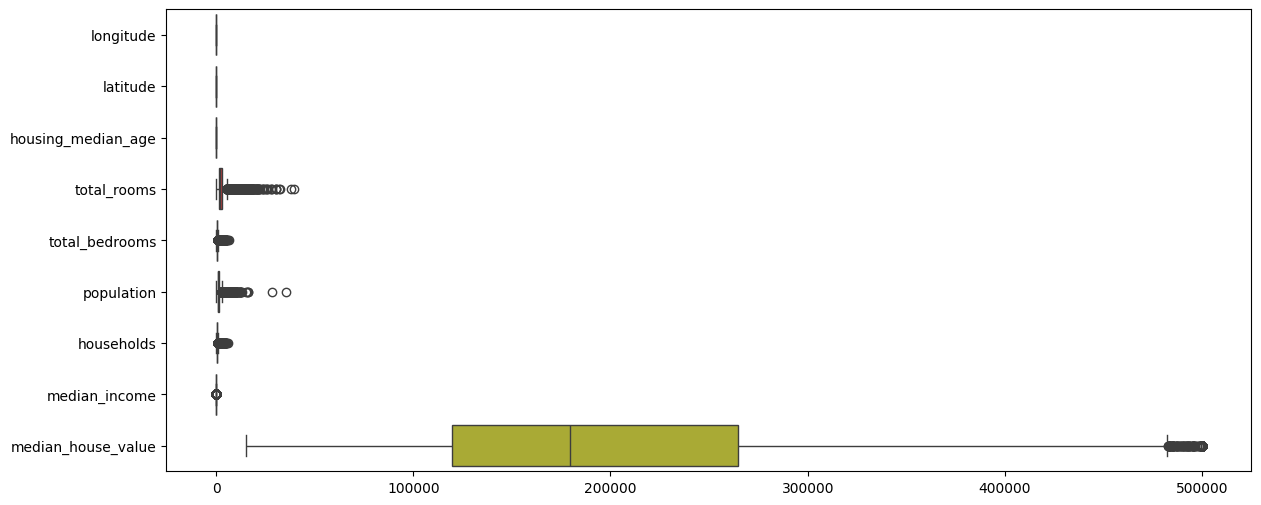

In [112]:
target_col = "median_house_value"

num_cols = housing.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# Outlier detection with IQR
iqr_bounds = {}
summary = []

for col in num_cols:
    q1 = housing[col].quantile(0.25)
    q3 = housing[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (housing[col] < lower) | (housing[col] > upper)

    iqr_bounds[col] = (lower, upper)
    summary.append({
        "feature": col,
        "n_outliers": int(mask.sum()),
        "pct_outliers": float(mask.mean() * 100),
        "lower_bound": float(lower),
        "upper_bound": float(upper),
    })

outlier_report = pd.DataFrame(summary).sort_values("pct_outliers", ascending=False)
outlier_report

# Histograms
vars_to_plot = ["total_rooms", "total_bedrooms", "households", "population", "median_income"]
housing[vars_to_plot].hist(figsize=(10,10), bins=30)
plt.tight_layout()
plt.show()

# Boxplots
num_cols = housing.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14,6))
sn.boxplot(data=housing[num_cols], orient="h")
plt.show()

### Outlier Treatment
I choose capping strategy because there are some extreme values that can dominate the model.

In [113]:
housing_out = housing.copy()

for col, (lower, upper) in iqr_bounds.items():
    mask = (housing_out[col] < lower) | (housing_out[col] > upper)
    housing_out[f"{col}_is_outlier"] = mask.astype("int8")
    housing_out[col] = housing_out[col].clip(lower=lower, upper=upper)

housing_out.head()
housing = housing_out

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,longitude_is_outlier,latitude_is_outlier,housing_median_age_is_outlier,total_rooms_is_outlier,total_bedrooms_is_outlier,population_is_outlier,households_is_outlier,median_income_is_outlier
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013,452600.0,NEAR BAY,0,0,0,0,0,0,0,1
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013,358500.0,NEAR BAY,0,0,0,1,0,0,1,1
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257,352100.0,NEAR BAY,0,0,0,0,0,0,0,0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643,341300.0,NEAR BAY,0,0,0,0,0,0,0,0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846,342200.0,NEAR BAY,0,0,0,0,0,0,0,0


### Feature engineering
In this section we create new meaningful variables. We will create:
- rooms_per_household = total_rooms / households
- bedrooms_per_room = total_bedrooms / total_rooms
- population_per_household = population / households
- rooms_per_person = total_rooms / population
- bedrooms_per_person = total_bedrooms / population
- income_x_rooms = median_income * rooms_per_household
- age_bin (new, mid, old, very_old)

array([[<Axes: title={'center': 'rooms_per_household_FE'}>,
        <Axes: title={'center': 'bedrooms_per_room_FE'}>],
       [<Axes: title={'center': 'population_per_household_FE'}>,
        <Axes: title={'center': 'rooms_per_person_FE'}>],
       [<Axes: title={'center': 'bedrooms_per_person_FE'}>,
        <Axes: title={'center': 'income_x_rooms_FE'}>]], dtype=object)

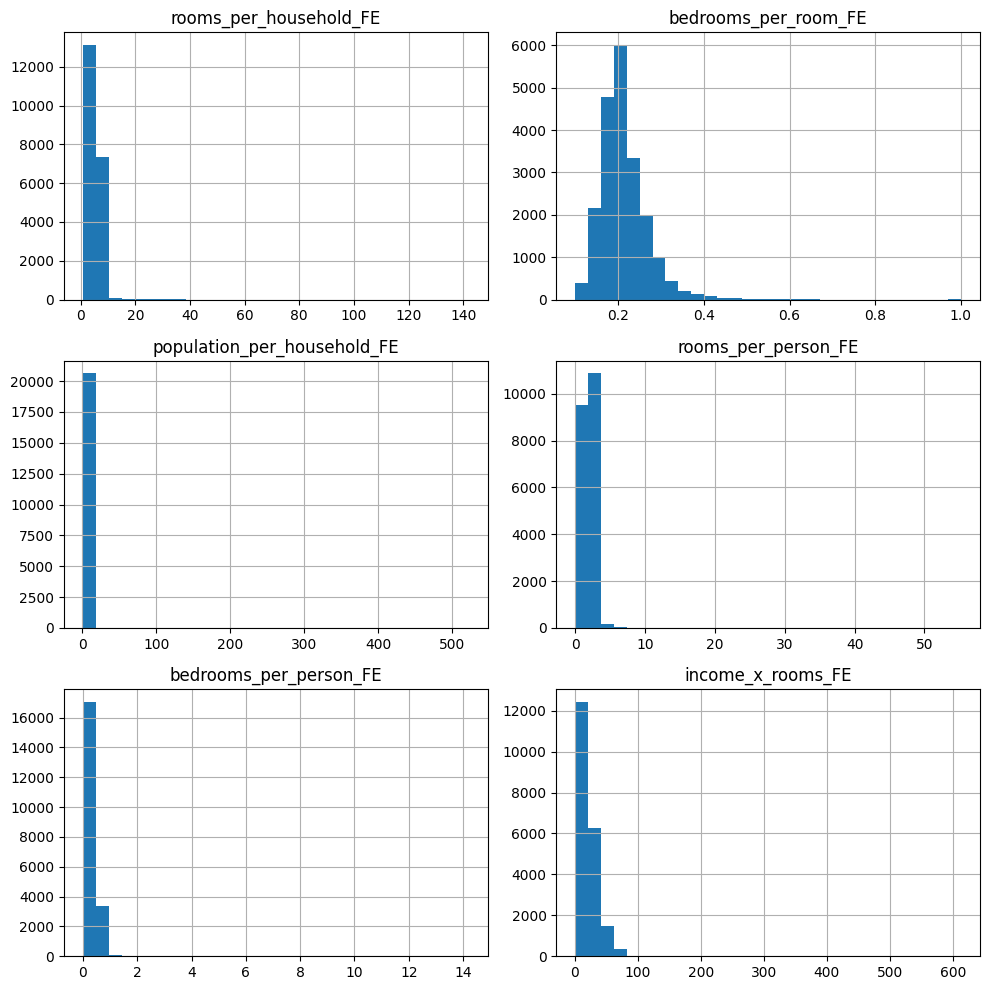

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='age_bin_FE', ylabel='count'>

Text(0.5, 1.0, 'Age_bin distribution')

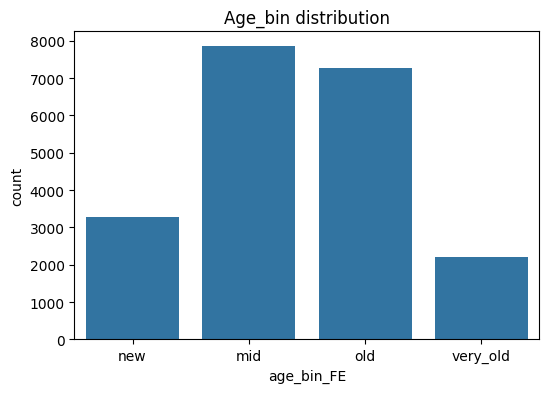

In [114]:
housing_fe = housing.copy()

# Avoid division by 0
eps = 1e-6
households = housing_fe["households"].clip(lower=eps)
rooms = housing_fe["total_rooms"].clip(lower=eps)
population = housing_fe["population"].clip(lower=eps)

housing_fe["rooms_per_household_FE"] = housing_fe["total_rooms"] / households
housing_fe["bedrooms_per_room_FE"] = housing_fe["total_bedrooms"] / rooms
housing_fe["population_per_household_FE"] = housing_fe["population"] / households
housing_fe["rooms_per_person_FE"] = housing_fe["total_rooms"] / population
housing_fe["bedrooms_per_person_FE"] = housing_fe["total_bedrooms"] / population
housing_fe["income_x_rooms_FE"] = housing_fe["median_income"] * housing_fe["rooms_per_household_FE"]

housing_fe["age_bin_FE"] = pd.cut(
    housing_fe["housing_median_age"],
    bins=[0, 15, 30, 45, 60],
    labels=["new", "mid", "old", "very_old"],
    include_lowest=True
)

# Plot histograms of new variables
vars_to_plot = ["rooms_per_household_FE", "bedrooms_per_room_FE", "population_per_household_FE", "rooms_per_person_FE", "bedrooms_per_person_FE", "income_x_rooms_FE"]
housing_fe[vars_to_plot].hist(figsize=(10,10), bins=30)
plt.tight_layout()
plt.show()

# Plot age_bin
plt.figure(figsize=(6,4))
sn.countplot(data=housing_fe, x="age_bin_FE", order=housing_fe["age_bin_FE"].cat.categories)
plt.title("Age_bin distribution")
plt.show()

housing = housing_fe


### Categorical Encoding

We convert categorical variables in one-hot encoded features.

In [115]:
# One-hot encoding of categorical variables
cat_cols = housing.select_dtypes(include=["object", "category"]).columns.tolist()

housing_ohe = pd.get_dummies(
    housing,
    columns=cat_cols,
    drop_first=False,
    dtype="int8"
)

print("Categorical columns encoded:", cat_cols)
print("Original shape:", housing.shape)
print("Encoded shape:", housing_ohe.shape)

housing_ohe.head()

housing = housing_ohe

Categorical columns encoded: ['ocean_proximity', 'age_bin_FE']
Original shape: (20640, 25)
Encoded shape: (20640, 32)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,longitude_is_outlier,...,income_x_rooms_FE,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,age_bin_FE_new,age_bin_FE_mid,age_bin_FE_old,age_bin_FE_very_old
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013,452600.0,0,...,55.964,0,0,0,1,0,0,0,1,0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013,358500.0,0,...,41.795,0,0,0,1,0,0,1,0,0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257,352100.0,0,...,60.150,0,0,0,1,0,0,0,0,1
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643,341300.0,0,...,32.828,0,0,0,1,0,0,0,0,1
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846,342200.0,0,...,24.161,0,0,0,1,0,0,0,0,1


### Numerical Transformations and final dataset

In this section we will scale the variables using StandardScaler() (centering at 0 and setting variance to 1). This helps because many models depend on the scale of the variables. If one feature is in units of thousands and another in tenths, the larger one may “dominate” even though it is not more informative. We will split the data in train and test to produce the final dataset.

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = "median_house_value"

# Separate Train and Test sets
X = housing_ohe.drop(columns=[target_col]).copy()
y = housing_ohe[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale only non binary columns
binary_cols = [c for c in X_train.columns if set(X_train[c].dropna().unique()).issubset({0, 1})]
cols_to_scale = [c for c in X_train.columns if c not in binary_cols]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaled columns:", len(cols_to_scale))
print("Binary columns kept as 0/1:", len(binary_cols))

Scaled columns: 14
Binary columns kept as 0/1: 17


### Visualization of the final dataset

Numeric scaled variables: 14


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'rooms_per_household_FE'}>],
       [<Axes: title={'center': 'bedrooms_per_room_FE'}>,
        <Axes: title={'center': 'population_per_household_FE'}>,
        <Axes: title={'center': 'rooms_per_person_FE'}>]], dtype=object)

Text(0.5, 0.98, 'X_train_scaled - Histograms (first 12 scaled variables)')

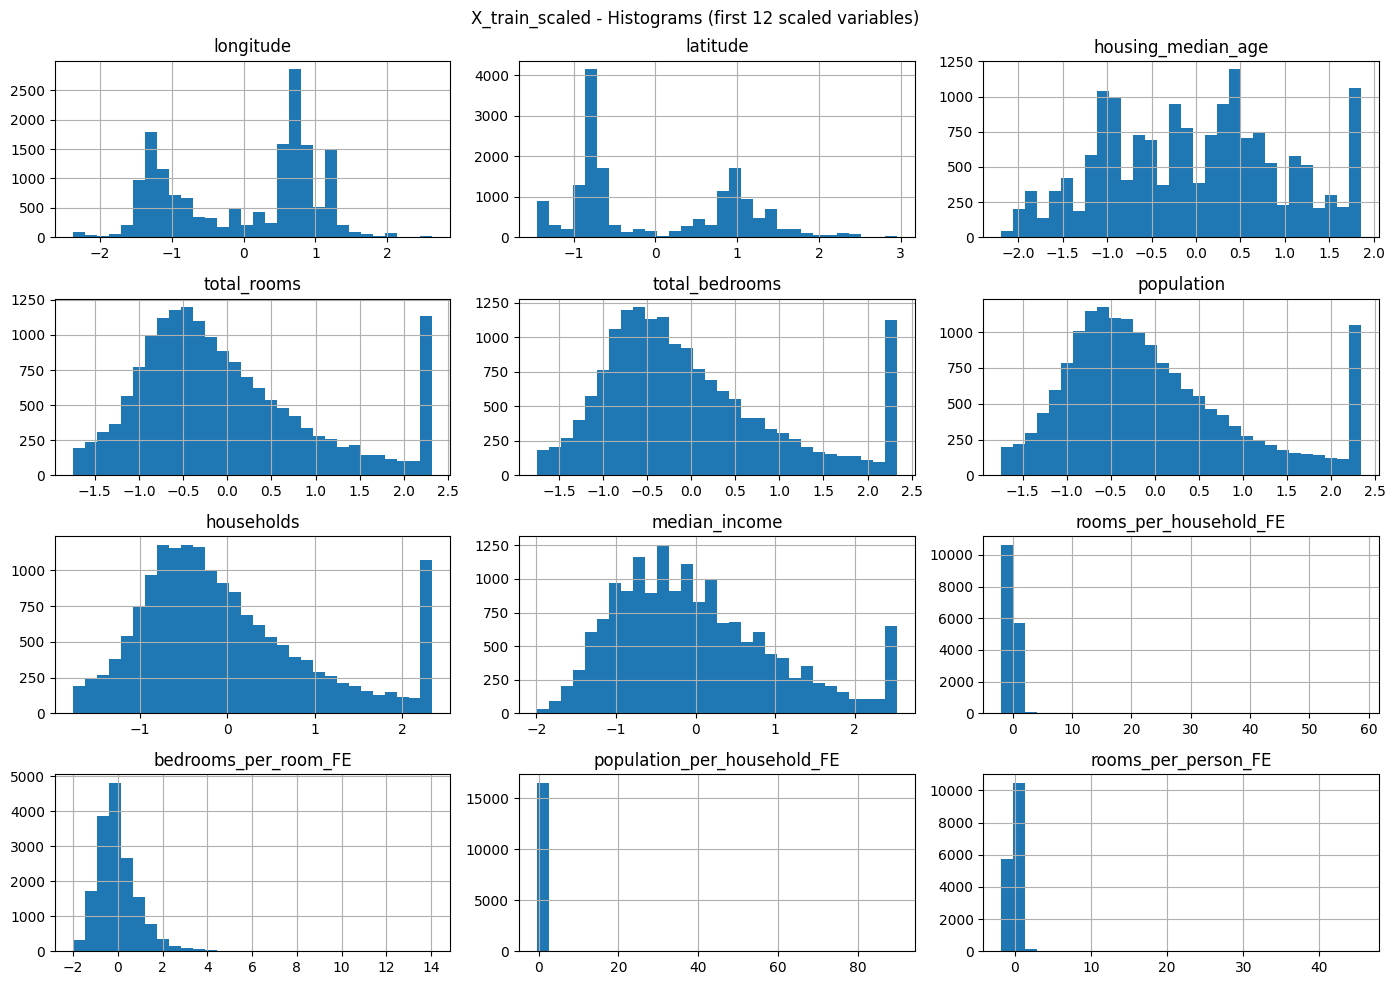

<Figure size 1400x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'X_train_scaled - Boxplots (first 12 scaled variables)')

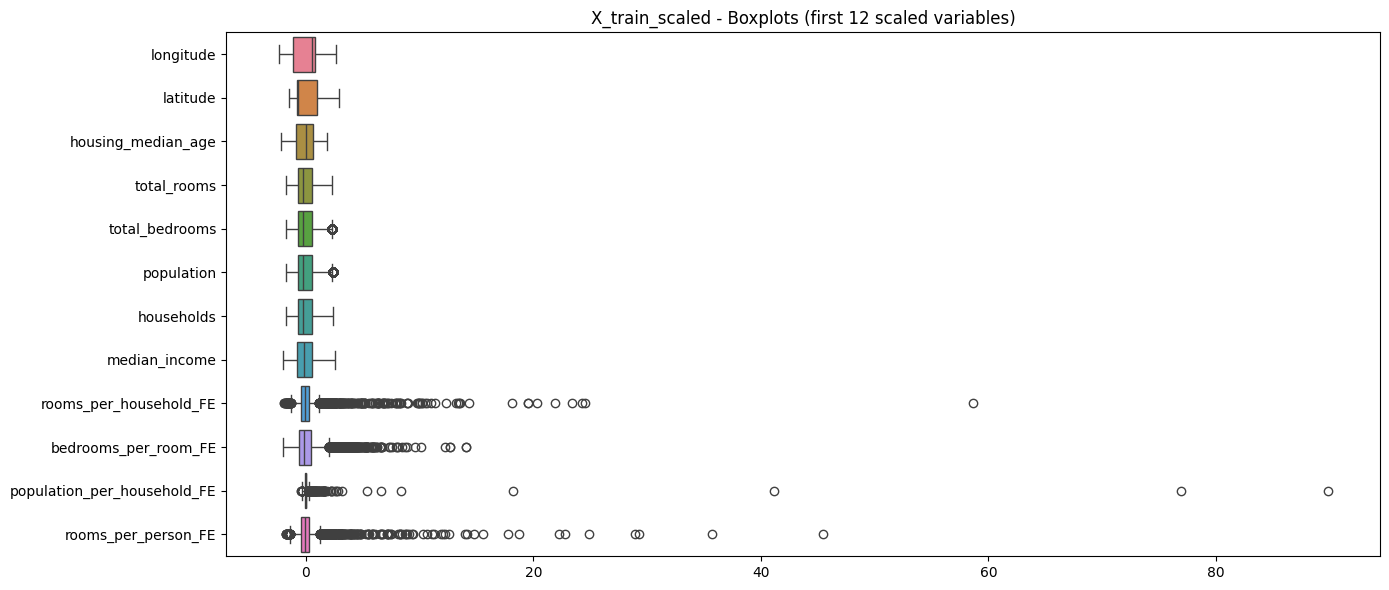

In [117]:
# Numeric variables to visualize (the scaled ones)
plot_cols = cols_to_scale.copy()

print(f"Numeric scaled variables: {len(plot_cols)}")

# Histograms (limit to first 12 to keep figure readable)
hist_cols = plot_cols[:12]
X_train_scaled[hist_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("X_train_scaled - Histograms (first 12 scaled variables)")
plt.tight_layout()
plt.show()

# Boxplot (same subset)
plt.figure(figsize=(14, 6))
sn.boxplot(data=X_train_scaled[hist_cols], orient="h")
plt.title("X_train_scaled - Boxplots (first 12 scaled variables)")
plt.tight_layout()
plt.show()